# **1. Perkenalan Dataset**


1. **Sumber Dataset**:  
    Dataset pada proyek ini bersumber dari kaggle dengan link: https://www.kaggle.com/datasets/imtkaggleteam/mental-health/code
    
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak memiliki label atau kelas.
   - **Jumlah Baris**: Dataset Mental Health memiliki 6420 baris
   - **Tipe Data**: Data sudah mengandung tipe numerik dan kategorikal.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
#Membaca dataset Mental Health dari github
df = pd.read_csv('https://raw.githubusercontent.com/Meicha15/Submission-Clastering/main/Mental%20Health.csv')
df.head()

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [3]:
#Menampilkan jumlah informasi dataset Mental Healt
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column                                                                             Non-Null Count  Dtype  
---  ------                                                                             --------------  -----  
 0   Entity                                                                             6420 non-null   object 
 1   Code                                                                               6150 non-null   object 
 2   Year                                                                               6420 non-null   int64  
 3   Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized  6420 non-null   float64
 4   Depressive disorders (share of population) - Sex: Both - Age: Age-standardized     6420 non-null   float64
 5   Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized        6420 non-null   float6

In [4]:
#Menampilkan statistika deskriptif dari dataset Mental Health
df.describe(include='all')

,Entity,Code,Year,Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized,Depressive disorders (share of population) - Sex: Both - Age: Age-standardized,Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized,Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized,Eating disorders (share of population) - Sex: Both - Age: Age-standardized
count,6420,6150,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
unique,214,205,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN
freq,30,30,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,NaN,NaN,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,NaN,NaN,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,NaN,NaN,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,NaN,NaN,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,NaN,NaN,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
#Rename kolom
rename = df.rename(columns={'Entity':'Negara', 'Year':'Tahun', 'Schizophrenia disorders (share of population) - Sex: Both - Age: Age-standardized': 'Schizophrenia disorders', 'Depressive disorders (share of population) - Sex: Both - Age: Age-standardized': 'Depressive disorders', 'Anxiety disorders (share of population) - Sex: Both - Age: Age-standardized': 'Anxiety disorders', 'Bipolar disorders (share of population) - Sex: Both - Age: Age-standardized': 'Bipolar disorders', 'Eating disorders (share of population) - Sex: Both - Age: Age-standardized': 'Eating disorders',
})

In [6]:
#Meninjau jumlah baris dan kolom pada dataset Mental Health
print('Jumlah baris dan kolom pada dataset Mental Health')
df.shape

Jumlah baris dan kolom pada dataset Mental Health


(6420, 8)

In [7]:
#Meninjau jenis data pada setiap kolom dataset Mental Health
print('Jenis data pada setiap kolom dataset Mental Health')
rename.dtypes

Jenis data pada setiap kolom dataset Mental Health


,0
Negara,object
Code,object
Tahun,int64
Schizophrenia disorders,float64
Depressive disorders,float64
Anxiety disorders,float64
Bipolar disorders,float64
Eating disorders,float64


In [8]:
#Cek missing value
print('Jumlah missing value pada dataset Mental Health')
rename.isnull().sum()

Jumlah missing value pada dataset Mental Health


,0
Negara,0
Code,270
Tahun,0
Schizophrenia disorders,0
Depressive disorders,0
Anxiety disorders,0
Bipolar disorders,0
Eating disorders,0


In [9]:
#Analisis distribusi variabel numerik dengan statistik deskriptif
print('Analisis distribusi variabel numerik')
rename.describe()

Analisis distribusi variabel numerik


,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders
count,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000,6420.000000
mean,2004.500000,0.266604,3.767036,4.101840,0.636968,0.195664
std,8.656116,0.039383,0.925286,1.050543,0.233391,0.138380
min,1990.000000,0.188416,1.522333,1.879996,0.181667,0.044780
25%,1997.000000,0.242267,3.080036,3.425846,0.520872,0.096416
50%,2004.500000,0.273477,3.636772,3.939547,0.579331,0.144150
75%,2012.000000,0.286575,4.366252,4.564164,0.844406,0.251167
max,2019.000000,0.462045,7.645899,8.624634,1.506730,1.031688


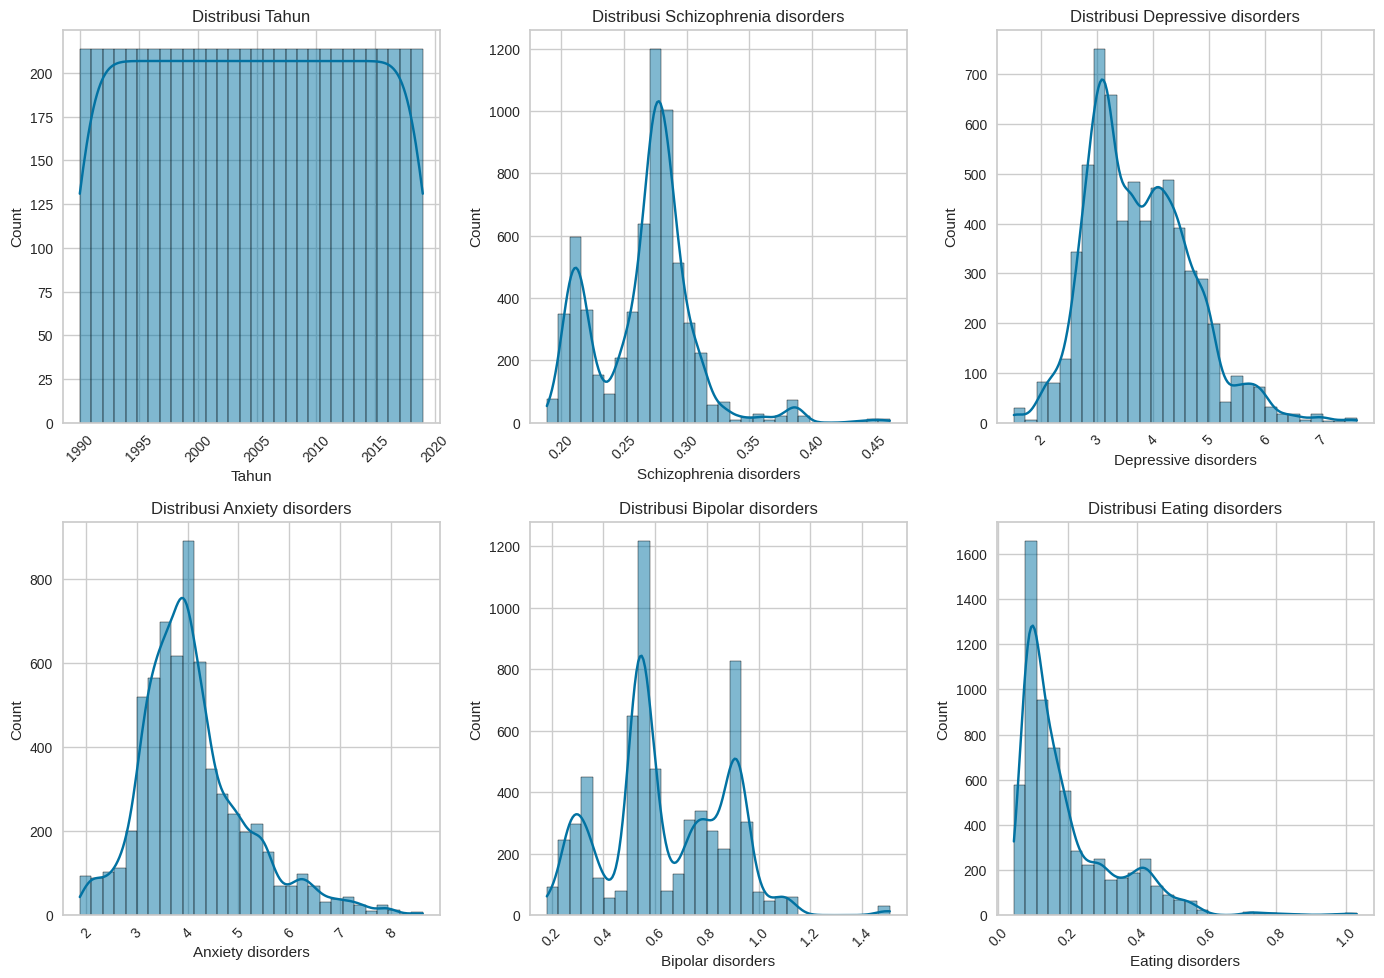

In [10]:
#Distribusi fitur numerik
numeric_features = rename.select_dtypes(include=[np.number])

# Menentukan jumlah kolom dan baris untuk subplot
num_cols = len(numeric_features.columns)
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Menghitung jumlah baris yang dibutuhkan

plt.figure(figsize=(14, 10))  # Menyesuaikan ukuran figure

for i, column in enumerate(numeric_features.columns, 1):
    plt.subplot(rows, 3, i)  # Menentukan posisi subplot
    sns.histplot(rename[column], bins=30, kde=True)
    plt.title(f'Distribusi {column}')
    plt.xticks(rotation=45)  # Memiringkan label sumbu X agar tidak bertumpuk jika perlu

plt.tight_layout()  # Mengatur tata letak agar lebih rapi
plt.show()

In [11]:
#Melihat jumlah negara pada dataset Mental Health
print('Jumlah negara pada dataset Mental Health')
rename['Negara'].value_counts()

Jumlah negara pada dataset Mental Health


,count
Negara,
Afghanistan,30
Africa (IHME GBD),30
Albania,30
Algeria,30
America (IHME GBD),30
...,...
Vietnam,30
World,30
Yemen,30


Menampilkan heatmap untuk menganalisis korelasi antar variabel


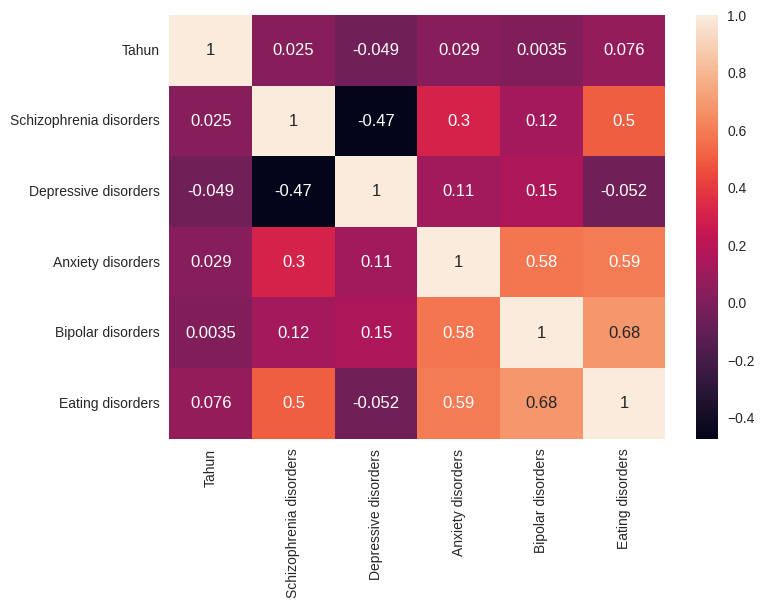

In [12]:
#Menampilkan heatmap untuk menganalisis korelasi antar variabel
print('Menampilkan heatmap untuk menganalisis korelasi antar variabel')
numerical_rename = rename.select_dtypes(include=np.number)
sns.heatmap(numerical_rename.corr(), annot=True)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [13]:
#Cek duplikasi data
print('Jumlah duplikasi data pada dataset Mental Health')
rename.duplicated().sum()

Jumlah duplikasi data pada dataset Mental Health


np.int64(0)

In [14]:
#Menghapus kolom "Code" pada dataset Mental Health
rename.drop('Code', axis=1, inplace=True)

In [15]:
#Memeriksa kembali dataset Mental Health
rename.head()

,Negara,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders
0,Afghanistan,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,1994,0.220183,4.977782,4.670810,0.699898,0.111815


In [16]:
numeric_features = rename.select_dtypes(include=[np.number]).columns

Melihat outlier dengan Boxplot


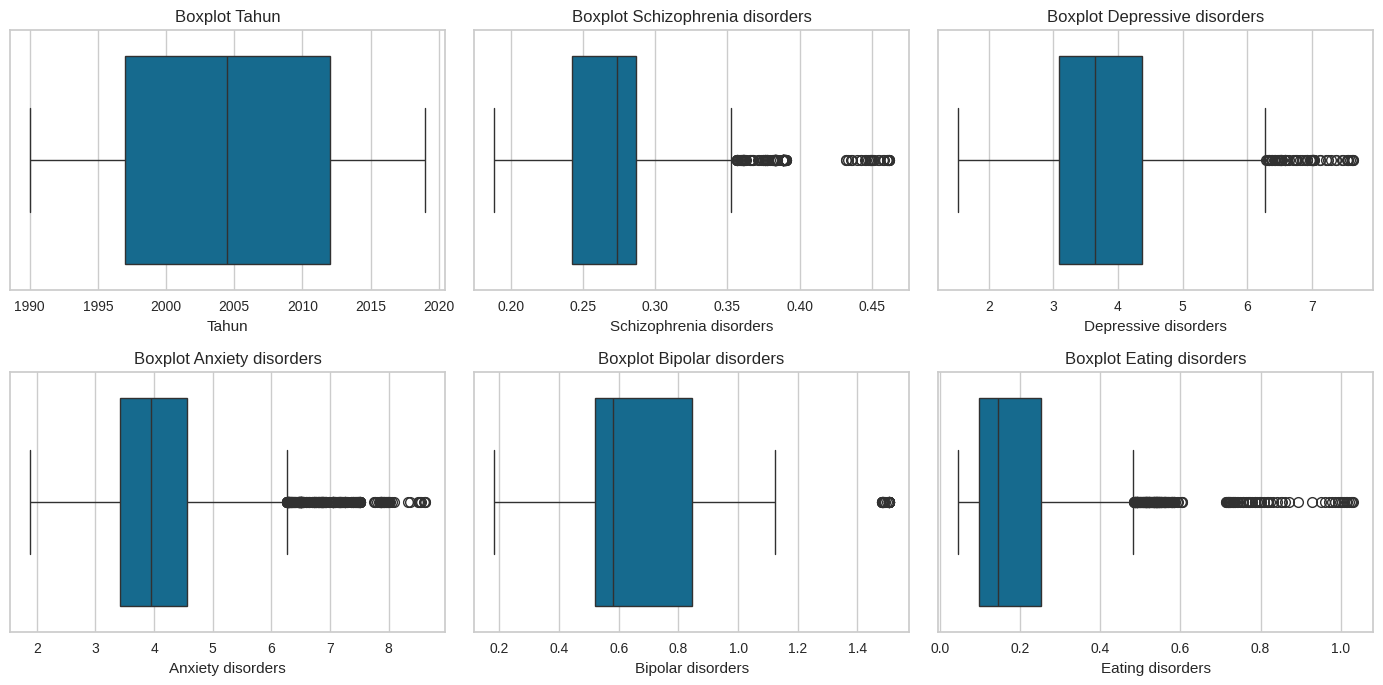

In [17]:
#Melihat outlier dengan Boxplot
print('Melihat outlier dengan Boxplot')
plt.figure(figsize=(14, 10))
for i, column in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=rename[column])
    plt.title(f'Boxplot {column}')
plt.tight_layout()
plt.show()

In [18]:
#Menangani Outlier dengan IQR
Q1 = rename[numeric_features].quantile(0.25)
Q3 = rename[numeric_features].quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = rename[~((rename[numeric_features] < (Q1 - 1.5 * IQR)) | (rename[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)]

Melihat hasil penanganan outlier dengan Boxplot


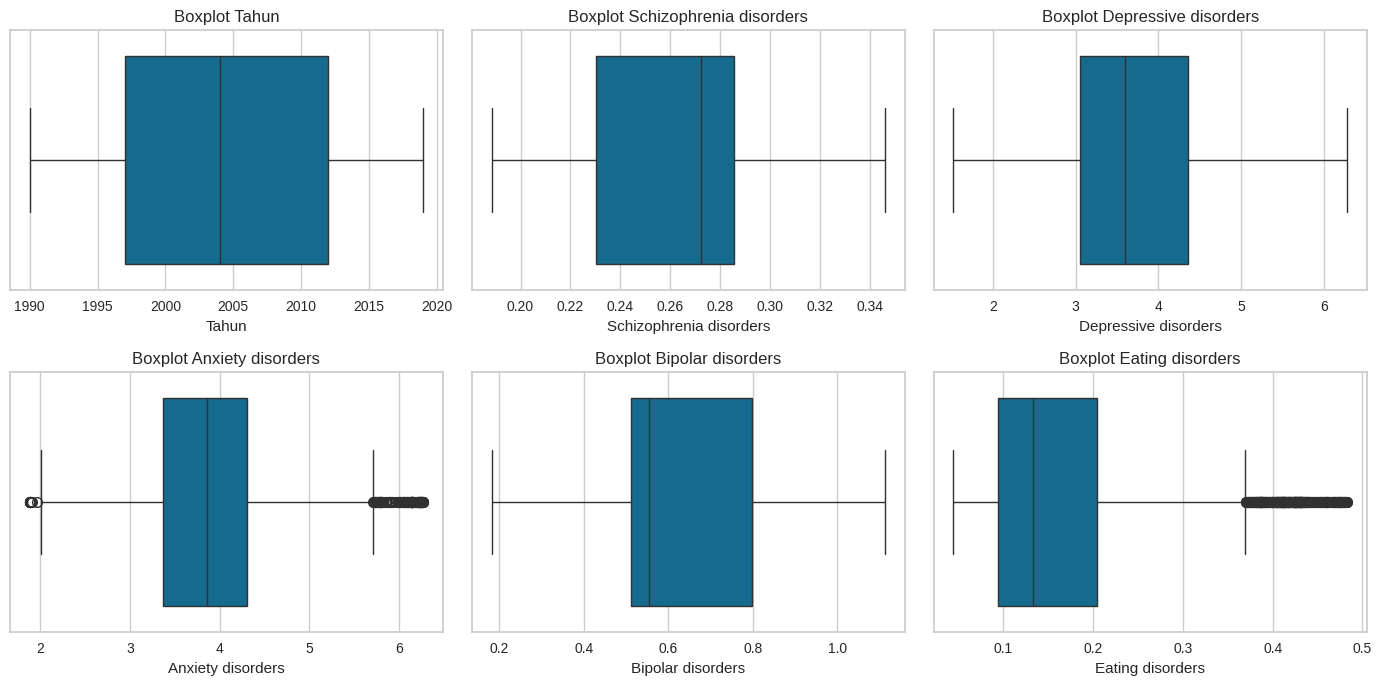

In [19]:
#Melihat hasil penanganan outlier dengan Boxplot
print('Melihat hasil penanganan outlier dengan Boxplot')
plt.figure(figsize=(14, 10))
for i, column in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_no_outliers[column])
    plt.title(f'Boxplot {column}')
plt.tight_layout()
plt.show()

In [20]:
#Standarisasi Fitur
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_no_outliers[numeric_features] = scaler.fit_transform(df_no_outliers[numeric_features])

<ipython-input-20-df052b6dd996>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers[numeric_features] = scaler.fit_transform(df_no_outliers[numeric_features])


In [21]:
#Melihat fitur yang sudah di standarisasi
df_no_outliers[numeric_features].head()

,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders
0,-1.653077,-1.152279,1.451005,1.028645,0.419945,-0.408524
1,-1.537906,-1.174370,1.443295,1.014656,0.415632,-0.452501
2,-1.422735,-1.195009,1.434325,0.991758,0.409861,-0.496158
3,-1.307564,-1.217451,1.429371,0.979041,0.406675,-0.533319
4,-1.192393,-1.241076,1.430301,0.975625,0.405820,-0.565719


In [22]:
#Encoding data kategorikal
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_encoded = rename.copy()
df_encoded['Negara'] = label_encoder.fit_transform(df_encoded['Negara'])

In [23]:
#Menampilkan hasil encoding untuk semua negara
df_encoded['Negara'].value_counts()

,count
Negara,
0,30
1,30
2,30
3,30
4,30
...,...
209,30
210,30
211,30


In [24]:
# Mendeskripsikan kolom yang akan di binning
column_to_bin = "Depressive disorders"
num_bins = 10

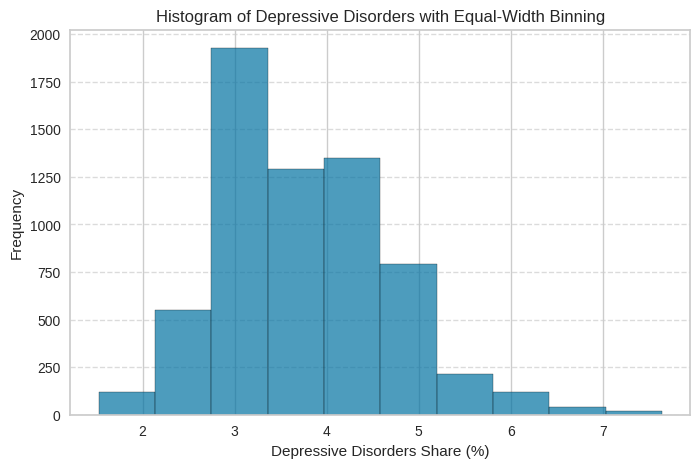

In [25]:
# Membuat plot histogram dengan binning
plt.figure(figsize=(8, 5))
rename[column_to_bin].hist(bins=num_bins, edgecolor='black', alpha=0.7)
plt.xlabel("Depressive Disorders Share (%)")
plt.ylabel("Frequency")
plt.title("Histogram of Depressive Disorders with Equal-Width Binning")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [26]:
# Mengambil kolom Schizophrenia disorders, Depressive disorders, Anxiety disorders, Bipolar disorders, Eating disorders
X = df_no_outliers[['Schizophrenia disorders', 'Depressive disorders', 'Anxiety disorders', 'Bipolar disorders', 'Eating disorders']].values

In [27]:
display(X)

array([[-1.15227881,  1.45100515,  1.02864498,  0.41994469, -0.40852434],
       [-1.17437003,  1.44329497,  1.01465645,  0.41563154, -0.45250103],
       [-1.1950086 ,  1.43432476,  0.99175762,  0.40986104, -0.49615821],
       ...,
       [-1.78583184, -0.33776715, -0.87353591, -0.32321547, -0.70905627],
       [-1.77592354, -0.34345408, -0.89387766, -0.32323369, -0.70332753],
       [-1.76107885, -0.35638688, -0.93765476, -0.32325479, -0.69949993]])

In [28]:
# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()

In [29]:
#Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1,10))

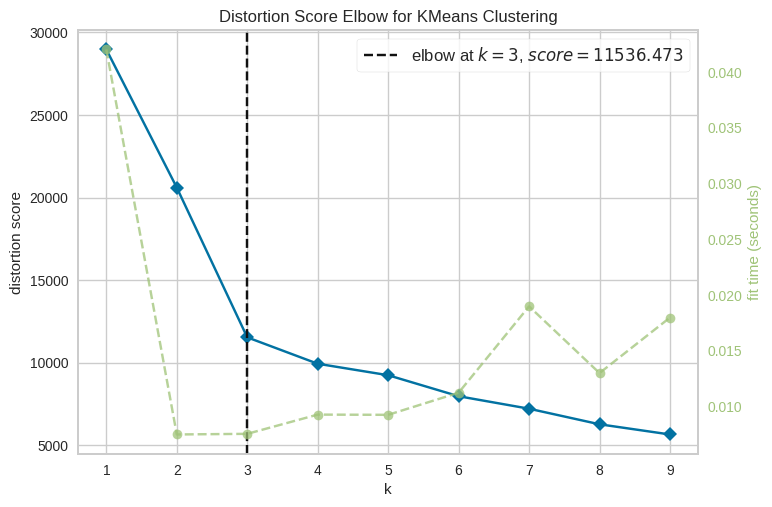

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [30]:
#Fit visualizer with only numerical data to find the optimal number of clusters
visualizer.fit(X)

#Menampilkan grafik Elbow untuk analisis
visualizer.show()

In [31]:
from sklearn.cluster import KMeans

#Inisialisasi dan melatih model KMeans dengan jumlah cluster = 3
kmeans = KMeans(n_clusters=3, random_state= 0)
kmeans.fit(df_no_outliers[numeric_features])

KMeans(n_clusters=3, random_state=0)

In [32]:
#Mendapatkan label cluster
labels = kmeans.labels_

#Mendapatkan jumlah cluster
k = 3

In [33]:
#Fungsi untuk analisis karakteristik cluster
def analyze_clusters(X, labels, k):
    print("Analisis Karakteristik Setiap Cluster:")
    for cluster_id in range(k):
        # Mengambil data untuk cluster saat ini
        cluster_data = X[labels == cluster_id]

        # Menghitung rata-rata untuk setiap fitur cluster
        mean_Schizophrenia = cluster_data[:, 0].mean()
        mean_Depressive = cluster_data[:, 1].mean()
        mean_Anxiety = cluster_data[:, 2].mean()
        mean_Bipolar = cluster_data[:, 3].mean()
        mean_Eating = cluster_data[:, 4].mean()

        # Menghitung min max setiap fitur cluster
        min_Schizophrenia = cluster_data[:, 0].min()
        min_Depressive = cluster_data[:, 1].min()
        min_Anxiety = cluster_data[:, 2].min()
        min_Bipolar = cluster_data[:, 3].min()
        min_Eating = cluster_data[:, 4].min()

        # Menghitung max untuk setiap fitur cluster
        max_Schizophrenia = cluster_data[:, 0].max()
        max_Depressive = cluster_data[:, 1].max()
        max_Anxiety = cluster_data[:, 2].max()
        max_Bipolar = cluster_data[:, 3].max()
        max_Eating = cluster_data[:, 4].max()

        print()
        print(f'Cluster {cluster_id + 1}:')
        print(f'Rata-rata fitur:')
        print(f'Schizophrenia: {mean_Schizophrenia:.2f}')
        print(f'Depressive: {mean_Depressive:.2f}')
        print(f'Anxiety: {mean_Anxiety:.2f}')
        print(f'Bipolar: {mean_Bipolar:.2f}')
        print(f'Eating: {mean_Eating:.2f}')

        print(f'Min fitur:')
        print(f'Schizophrenia: {min_Schizophrenia:.2f}')
        print(f'Depressive: {min_Depressive:.2f}')
        print(f'Anxiety: {min_Anxiety:.2f}')
        print(f'Bipolar: {min_Bipolar:.2f}')
        print(f'Eating: {min_Eating:.2f}')

        print(f'Max fitur:')
        print(f'Schizophrenia: {max_Schizophrenia:.2f}')
        print(f'Depressive: {max_Depressive:.2f}')
        print(f'Anxiety: {max_Anxiety:.2f}')
        print(f'Bipolar: {max_Bipolar:.2f}')
        print(f'Eating: {max_Eating:.2f}')

# Memanggil fungsi analisis karakteristik cluster
display(analyze_clusters(X, labels, k))

Analisis Karakteristik Setiap Cluster:

Cluster 1:
Rata-rata fitur:
Schizophrenia: 0.66
Depressive: -0.68
Anxiety: -0.50
Bipolar: -0.92
Eating: -0.44
Min fitur:
Schizophrenia: -0.34
Depressive: -2.47
Anxiety: -2.51
Bipolar: -1.94
Eating: -1.12
Max fitur:
Schizophrenia: 1.99
Depressive: 1.18
Anxiety: 0.89
Bipolar: 0.44
Eating: 2.73

Cluster 2:
Rata-rata fitur:
Schizophrenia: -1.42
Depressive: 1.08
Anxiety: -0.40
Bipolar: -0.17
Eating: -0.66
Min fitur:
Schizophrenia: -2.17
Depressive: -0.47
Anxiety: -1.57
Bipolar: -1.02
Eating: -1.23
Max fitur:
Schizophrenia: 0.31
Depressive: 2.90
Anxiety: 2.07
Bipolar: 0.82
Eating: 0.58

Cluster 3:
Rata-rata fitur:
Schizophrenia: 0.37
Depressive: -0.08
Anxiety: 0.88
Bipolar: 1.16
Eating: 1.01
Min fitur:
Schizophrenia: -1.41
Depressive: -2.00
Anxiety: -1.48
Bipolar: 0.30
Eating: -0.49
Max fitur:
Schizophrenia: 2.45
Depressive: 2.53
Anxiety: 2.97
Bipolar: 2.27
Eating: 3.10


None

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

In [34]:
# Hitung Silhouette Score sebagai ukuran kualitas cluster
silhouette_avg = silhouette_score(X, labels)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.43114071764201267


In [35]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)  # Pilih 5 fitur terbaik
df_selected = selector.fit_transform(X, labels)

In [36]:
best_score = -1
best_k = None

for k in range(2, 10):  # Coba berbagai nilai K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal K = {best_k} dengan Silhouette Score = {best_score:.4f}")

K = 2, Silhouette Score = 0.3543
K = 3, Silhouette Score = 0.4311
K = 4, Silhouette Score = 0.3895
K = 5, Silhouette Score = 0.3500
K = 6, Silhouette Score = 0.3474
K = 7, Silhouette Score = 0.3550
K = 8, Silhouette Score = 0.3245
K = 9, Silhouette Score = 0.3405
Optimal K = 3 dengan Silhouette Score = 0.4311


In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(df_pca)

silhouette_avg = silhouette_score(df_pca, labels)
print("Silhouette Score after PCA:", silhouette_avg)


Silhouette Score after PCA: 0.5618738906982851


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

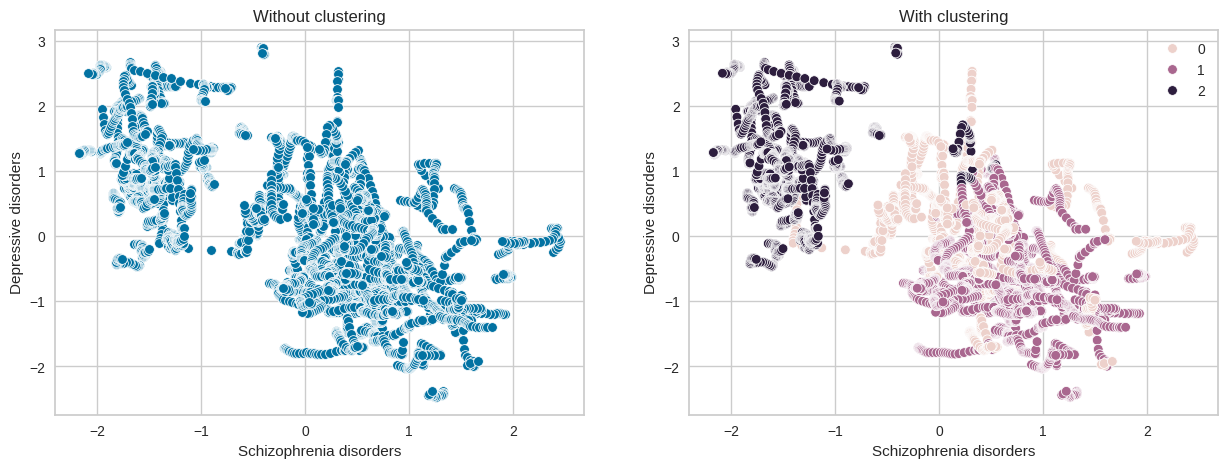

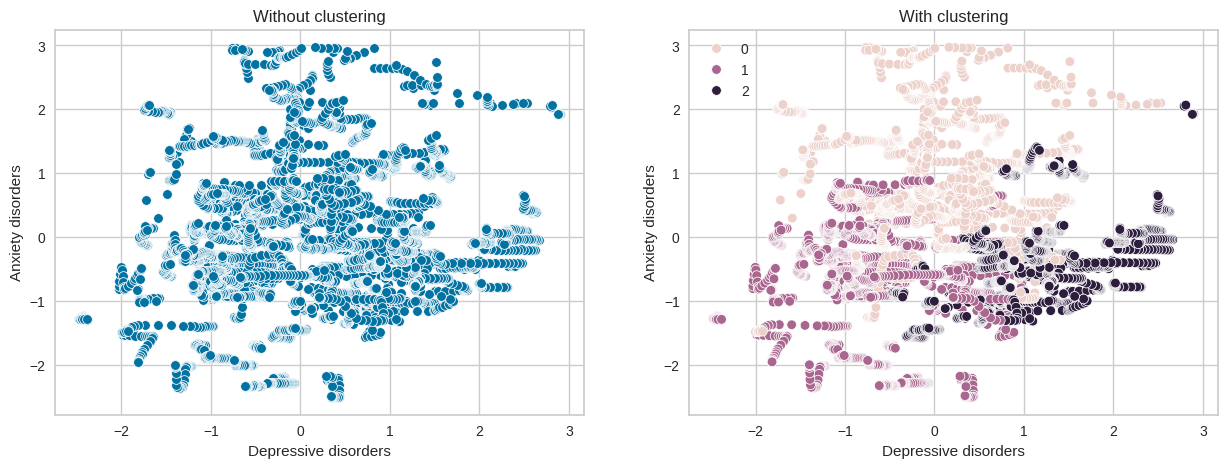

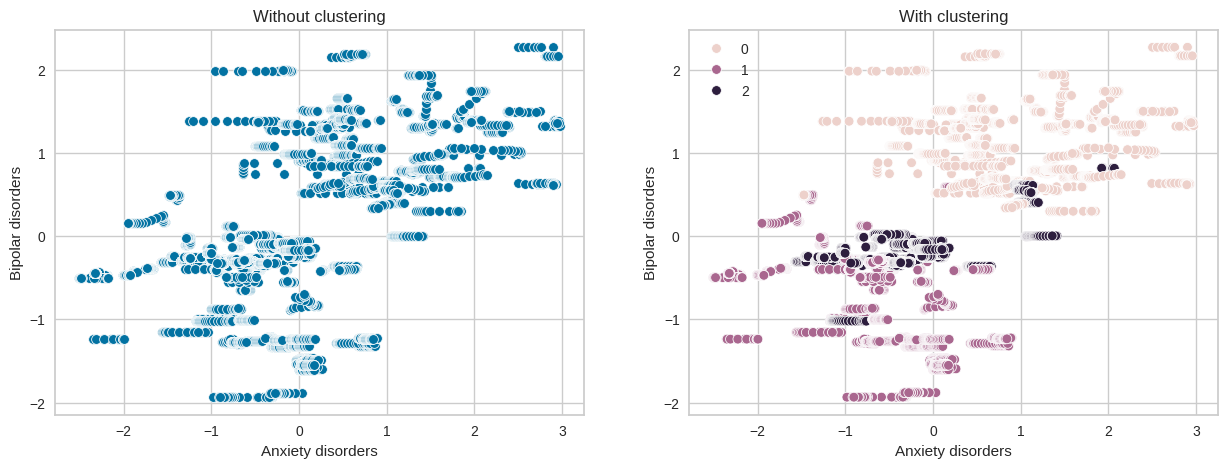

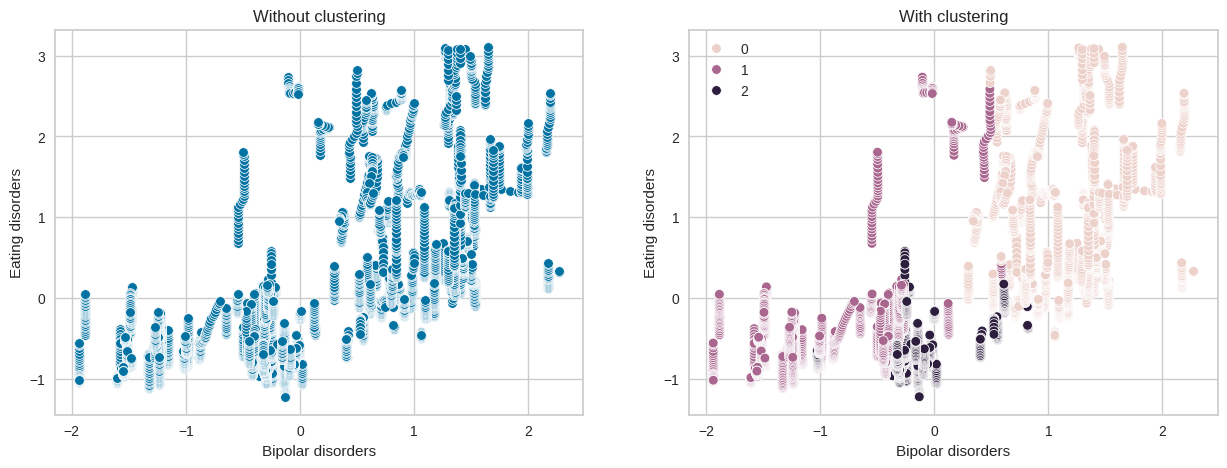

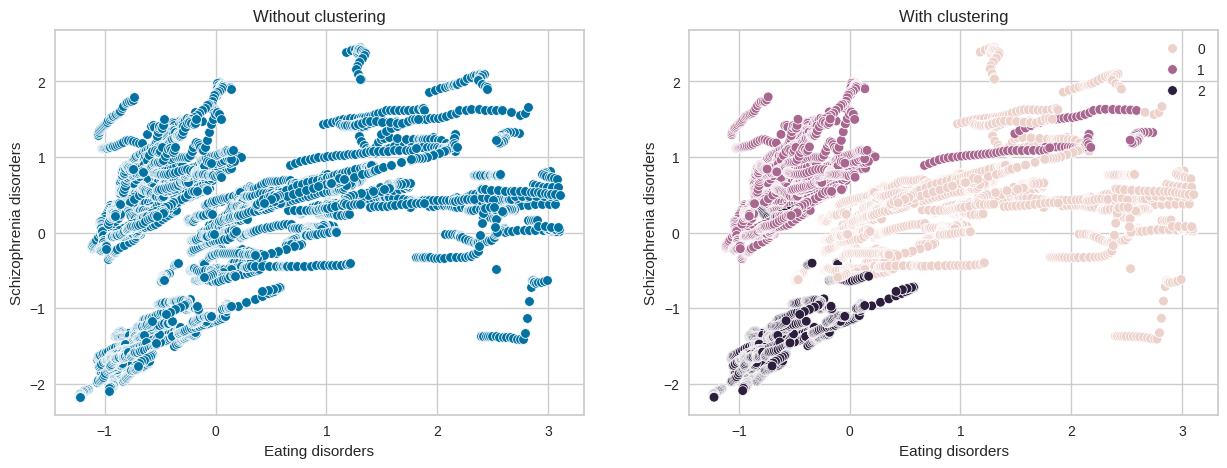

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.scatterplot(ax=axes[0], data=df_no_outliers, x='Schizophrenia disorders',
                y='Depressive disorders').set_title('Without clustering')
sns.scatterplot(ax=axes[1], data=df_no_outliers, x='Schizophrenia disorders',
                y='Depressive disorders', hue=labels).set_title('With clustering'); # Use labels instead of labels_Km


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.scatterplot(ax=axes[0], data=df_no_outliers, x='Depressive disorders',
                y='Anxiety disorders').set_title('Without clustering')
sns.scatterplot(ax=axes[1], data=df_no_outliers, x='Depressive disorders',
                y='Anxiety disorders', hue=labels).set_title('With clustering');


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.scatterplot(ax=axes[0], data=df_no_outliers, x='Anxiety disorders',
                y='Bipolar disorders').set_title('Without clustering')
sns.scatterplot(ax=axes[1], data=df_no_outliers, x='Anxiety disorders',
                y='Bipolar disorders', hue=labels).set_title('With clustering');


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.scatterplot(ax=axes[0], data=df_no_outliers, x='Bipolar disorders',
                y='Eating disorders').set_title('Without clustering')
sns.scatterplot(ax=axes[1], data=df_no_outliers, x='Bipolar disorders',
                y='Eating disorders', hue=labels).set_title('With clustering');


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
sns.scatterplot(ax=axes[0], data=df_no_outliers, x='Eating disorders',
                y='Schizophrenia disorders').set_title('Without clustering')
sns.scatterplot(ax=axes[1], data=df_no_outliers, x='Eating disorders',
                y='Schizophrenia disorders', hue=labels).set_title('With clustering');

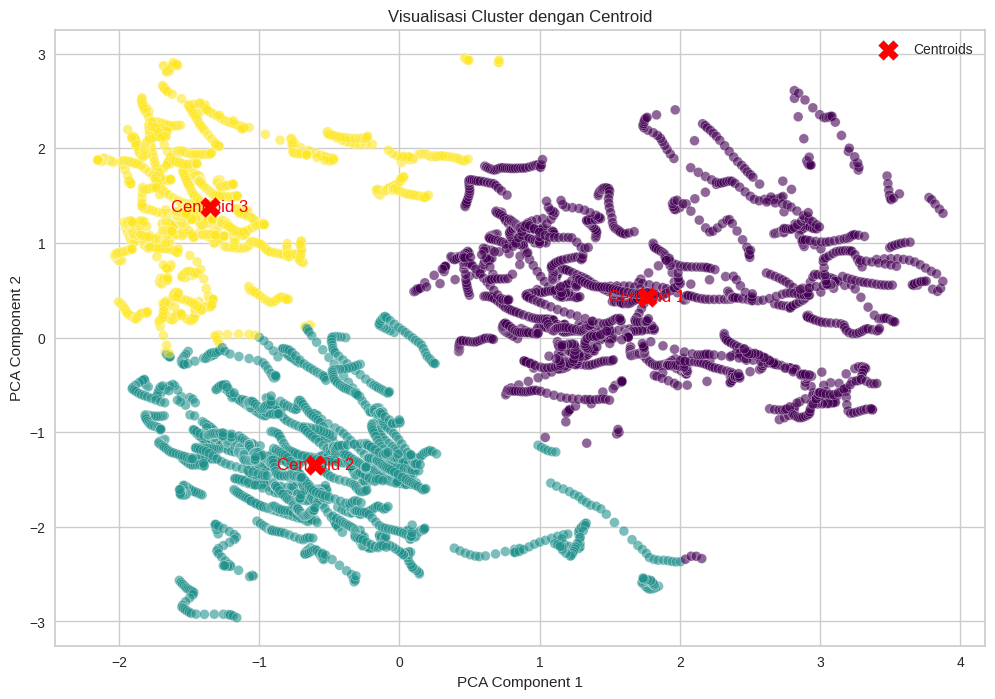

Nilai Centroids dalam PCA Projection:
Centroid 1: PCA1 = 1.76, PCA2 = 0.42
Centroid 2: PCA1 = -0.60, PCA2 = -1.34
Centroid 3: PCA1 = -1.35, PCA2 = 1.38


In [39]:
# Menggunakan PCA untuk reduksi dimensi ke 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Fit KMeans pada data yang sudah direduksi dimensinya (X_pca)
kmeans = KMeans(n_clusters=3, random_state=42)  # Inisialisasi KMeans di sini
kmeans.fit(X_pca)  # Fit KMeans pada data yang sudah direduksi

# Mendapatkan centroid dari model KMeans yang sudah difit pada data yang direduksi
centroids_pca = kmeans.cluster_centers_  # Centroid sudah dalam 2D

# Plot hasil clustering
plt.figure(figsize=(12, 8))

# Scatter plot data dengan warna sesuai cluster
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, edgecolors='w')

# Scatter plot centroid dalam bentuk 'X' merah
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

# Menambahkan label centroid
for i, centroid in enumerate(centroids_pca):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

# Menambahkan judul dan label sumbu
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()

plt.show()

# Menampilkan nilai centroid
print("Nilai Centroids dalam PCA Projection:")
for i, centroid in enumerate(centroids_pca):
    print(f"Centroid {i+1}: PCA1 = {centroid[0]:.2f}, PCA2 = {centroid[1]:.2f}")

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [40]:
df_no_outliers['Cluster'] = kmeans.labels_

<ipython-input-40-af8d34b558af>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Cluster'] = kmeans.labels_


In [41]:
df_encoded['Negara'] = label_encoder.inverse_transform(df_encoded['Negara'])

In [42]:
# Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
df_no_outliers['Negara'] = df_encoded['Negara']

<ipython-input-42-bbb4eb7ce190>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Negara'] = df_encoded['Negara']


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [43]:
df_original = df_no_outliers.copy()
df_original[numeric_features] = scaler.inverse_transform(df_no_outliers[numeric_features])

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [44]:
# Melihat hasil cluster
display(df_original)

,Negara,Tahun,Schizophrenia disorders,Depressive disorders,Anxiety disorders,Bipolar disorders,Eating disorders,Cluster
0,Afghanistan,1990.0,0.223206,4.996118,4.713314,0.703023,0.127700,2
1,Afghanistan,1991.0,0.222454,4.989290,4.702100,0.702069,0.123256,2
2,Afghanistan,1992.0,0.221751,4.981346,4.683743,0.700792,0.118844,2
3,Afghanistan,1993.0,0.220987,4.976958,4.673549,0.700087,0.115089,2
4,Afghanistan,1994.0,0.220183,4.977782,4.670810,0.699898,0.111815,2
...,...,...,...,...,...,...,...,...
6415,Zimbabwe,2015.0,0.201042,3.407624,3.184012,0.538596,0.095652,2
6416,Zimbabwe,2016.0,0.201319,3.410755,3.187148,0.538593,0.096662,2
6417,Zimbabwe,2017.0,0.201639,3.411965,3.188418,0.538589,0.097330,2
6418,Zimbabwe,2018.0,0.201976,3.406929,3.172111,0.538585,0.097909,2


In [45]:
#Membuat agregasi untuk mean, min, max
agg_data = df_original.select_dtypes(include=np.number).groupby('Cluster').agg(['mean', 'min', 'max'])
display(agg_data)

Tahun                 Schizophrenia disorders            \
                mean     min     max                    mean       min   
Cluster                                                                  
0        2004.079615  1990.0  2019.0                0.274678  0.214583   
1        2004.533929  1990.0  2019.0                0.285246  0.250707   
2        2004.438608  1990.0  2019.0                0.214799  0.188416   

                  Depressive disorders                     Anxiety disorders  \
              max                 mean       min       max              mean   
Cluster                                                                        
0        0.345895             3.653306  1.954629  5.950096          4.611923   
1        0.330059             3.085672  1.522333  4.759049          3.482154   
2        0.281006             4.669897  3.299060  6.277466          3.562392   

                            Bipolar disorders                      \
              min       max              mean       min       max   
Cluster                                                             
0        2.699509  6.271558          0.868923  0.675939  1.112766   
1        1.879996  4.606148          0.409603  0.181667  0.740559   
2        2.629187  5.545805          0.571329  0.383906  0.792147   

        Eating disorders                      
                    mean       min       max  
Cluster                                       
0               0.270232  0.119093  0.482690  
1               0.126493  0.056217  0.445312  
2               0.102855  0.044780  0.227705

Tulis hasil interpretasinya di sini.
1. Cluster 0:
  * Rentang tahun: 1990 - 2019 (mean: 2004.08)

  * Schizophrenia disorders: Rata-rata 0.274678, dengan variasi antara 0.214583 - 0.345895.

  * Depressive disorders: Rata-rata 3.653306, dengan variasi 1.954629 - 5.950096.

  * Anxiety disorders: Rata-rata 4.611923, dengan variasi 2.699509 - 6.271558.

  * Bipolar disorders: Rata-rata 0.868923, dengan variasi 0.675939 - 1.112766.

  * Eating disorders: Rata-rata 0.270232, dengan variasi 0.119093 - 0.482690.

    **Kesimpulan**: Cluster ini cenderung memiliki tingkat gangguan mental tertinggi dibandingkan cluster lain, terutama pada depresi, kecemasan, dan bipolar disorder.

2. Cluster 1:
  * Rentang tahun: 1990 - 2019 (mean: 2004.53)

  * Schizophrenia disorders: Rata-rata 0.285246, dengan variasi 0.250707 - 0.330059.

  * Depressive disorders: Rata-rata 3.085672, dengan variasi 1.522333 - 4.759049.

  * Anxiety disorders: Rata-rata 3.482154, dengan variasi 1.879996 - 4.606148.

  * Bipolar disorders: Rata-rata 0.409603, dengan variasi 0.181667 - 0.740559.

  * Eating disorders: Rata-rata 0.126493, dengan variasi 0.056217 - 0.445312.

    **Kesimpulan**: Cluster ini memiliki tingkat gangguan mental lebih rendah dibanding Cluster 0, terutama pada depresi, kecemasan, dan bipolar disorder.

3. Cluster 2:
  * Rentang tahun: 1990 - 2019 (mean: 2004.44)

  * Schizophrenia disorders: Rata-rata 0.214799, dengan variasi 0.188416 - 0.281006.

  * Depressive disorders: Rata-rata 4.669897, dengan variasi 3.299060 - 6.277466.

  * Anxiety disorders: Rata-rata 3.562392, dengan variasi 2.629187 - 5.545805.

  * Bipolar disorders: Rata-rata 0.571329, dengan variasi 0.383906 - 0.792147.

  * Eating disorders: Rata-rata 0.102855, dengan variasi 0.044780 - 0.227705.
  
    **Kesimpulan**: Cluster ini menunjukkan depresi yang paling tinggi di antara cluster lainnya, tetapi gangguan lainnya relatif lebih rendah dibanding Cluster 0.

**Kesimpulan Keseluruhan**:
* Cluster 0 memiliki tingkat gangguan mental tertinggi secara umum, khususnya pada depresi, kecemasan, dan bipolar disorder.

* Cluster 1 memiliki tingkat gangguan mental yang lebih ringan dibandingkan Cluster 0.

* Cluster 2 memiliki depresi paling tinggi, tetapi gangguan mental lainnya cenderung lebih rendah dibandingkan Cluster 0.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [46]:
#Simpan semua hasil ke dalam file CSV
df_original.to_csv('hasil_clustering.csv', index=False)